IMPORTING THE DATASET

In [ ]:
import numpy as np
import idx2numpy
import matplotlib.pyplot as plt

# Folder containing the MNIST files
DATA_DIR = ""

# Load training data
X_train = idx2numpy.convert_from_file(f"{DATA_DIR}/train-images.idx3-ubyte")
y_train = idx2numpy.convert_from_file(f"{DATA_DIR}/train-labels.idx1-ubyte")

# Load test data
X_test = idx2numpy.convert_from_file(f"{DATA_DIR}/t10k-images.idx3-ubyte")
y_test = idx2numpy.convert_from_file(f"{DATA_DIR}/t10k-labels.idx1-ubyte")

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'mnist images dataset/train-images.idx3-ubyte'

FLATTEN THE IMAGES

In [ ]:
# Convert each 28x28 image into a vector of length 784
X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test = X_test.reshape(-1, 784).astype(np.float32) / 255.0

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


COMBINE THE LABELS AND IMAGES

In [ ]:
data = np.column_stack((y_train, X_train))

print(data.shape)

(60000, 785)


DISPLAYING AN EXAMPLE IMAGE

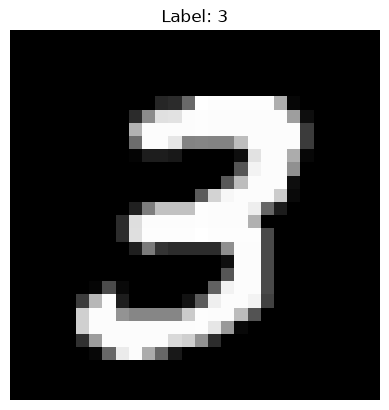

In [ ]:
index = 7 #CHANGE ACCORDINGLY TO SEE DIFFERENT IMAGES

plt.imshow(X_train[index].reshape(28, 28), cmap="gray")
plt.title(f"Label: {y_train[index]}")
plt.axis("off")
plt.show()

In [ ]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]
X_dev = X_dev / 255.

data_train = data[1000:m].T

Y_train = data_train[0].astype(int)

X_train = data_train[1:n]

data_dev = data[0:1000].T

Y_dev = data_dev[0].astype(int)

X_dev = data_dev[1:n]

_,m_train = X_train.shape

In [ ]:
Y_train


array([4, 9, 4, ..., 2, 1, 1], shape=(59000,))

ALL THE FUNCTION WE NEED TO ESTABLISH THE NERUAL NETWORK

In [ ]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    Y = Y.astype(int)

    one_hot_Y = np.zeros((Y.size, int(Y.max()) + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T

    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

In [ ]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[4 7 5 ... 4 1 7] [4 9 4 ... 2 1 1]
0.08189830508474576
Iteration:  10
[5 7 5 ... 5 7 8] [4 9 4 ... 2 1 1]
0.10976271186440678
Iteration:  20
[5 7 5 ... 5 7 8] [4 9 4 ... 2 1 1]
0.17940677966101695
Iteration:  30
[5 0 5 ... 0 1 8] [4 9 4 ... 2 1 1]
0.25240677966101693
Iteration:  40
[0 0 5 ... 0 1 8] [4 9 4 ... 2 1 1]
0.2944915254237288
Iteration:  50
[0 5 5 ... 0 1 8] [4 9 4 ... 2 1 1]
0.3363898305084746
Iteration:  60
[0 5 5 ... 5 1 8] [4 9 4 ... 2 1 1]
0.3713728813559322
Iteration:  70
[0 5 5 ... 5 1 8] [4 9 4 ... 2 1 1]
0.4025762711864407
Iteration:  80
[0 5 5 ... 5 1 1] [4 9 4 ... 2 1 1]
0.433135593220339
Iteration:  90
[5 4 4 ... 2 1 1] [4 9 4 ... 2 1 1]
0.46484745762711865
Iteration:  100
[5 4 4 ... 2 1 1] [4 9 4 ... 2 1 1]
0.4963559322033898
Iteration:  110
[5 4 4 ... 2 1 1] [4 9 4 ... 2 1 1]
0.528
Iteration:  120
[5 4 4 ... 2 1 1] [4 9 4 ... 2 1 1]
0.5637118644067797
Iteration:  130
[5 9 4 ... 2 1 1] [4 9 4 ... 2 1 1]
0.5942542372881356
Iteration:  140
[5 9 4 ...

In [ ]:
print(X_train.shape)
print(Y_train.shape)

print(X_train.dtype)
print(Y_train.dtype)

print(np.min(X_train), np.max(X_train))

print(np.unique(Y_train))

(784, 59000)
(59000,)
float32
int64
0.0 1.0
[0 1 2 3 4 5 6 7 8 9]


In [ ]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [3]
Label:  3


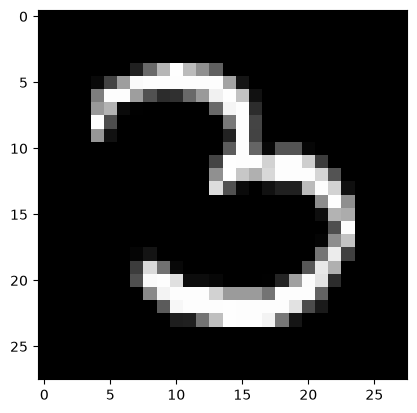

Prediction:  [4]
Label:  4


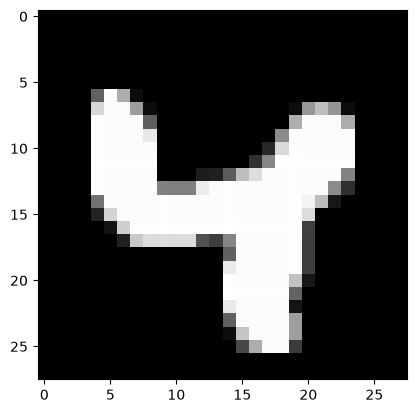

Prediction:  [4]
Label:  4


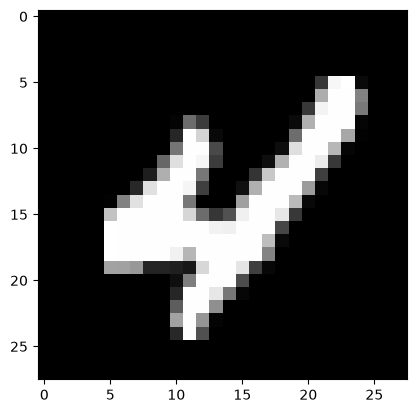

Prediction:  [8]
Label:  3


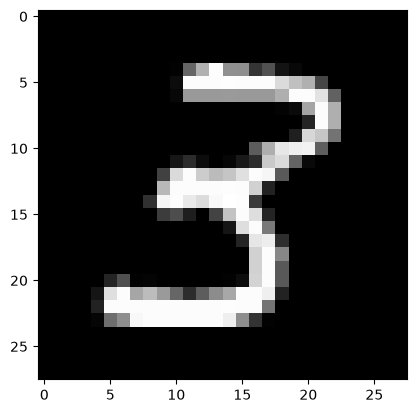

In [ ]:
test_prediction(66, W1, b1, W2, b2)
test_prediction(9, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [ ]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[4 6 1 9 4 1 8 6 9 5 7 8 7 9 7 1 7 4 7 5 8 3 5 7 6 3 2 4 6 0 7 3 4 9 7 9 6
 6 7 2 4 0 2 4 6 7 8 0 3 8 5 2 9 9 5 6 6 3 8 1 3 0 7 1 3 2 4 5 1 1 4 5 8 7
 0 8 3 3 5 9 5 9 7 6 1 9 2 8 6 5 5 2 7 5 8 0 6 2 5 5 3 1 6 1 0 3 1 1 8 2 2
 2 5 4 5 0 0 6 8 5 6 5 5 8 1 1 8 8 2 2 1 6 4 1 5 6 2 3 8 5 8 1 4 4 3 8 0 9
 8 9 8 1 4 3 2 4 3 5 4 5 3 7 3 3 7 1 7 3 5 5 8 2 6 6 1 0 0 4 2 0 2 9 8 9 4
 6 7 0 9 0 6 0 7 1 7 0 0 1 7 4 3 9 2 7 8 5 9 5 1 6 6 0 7 8 6 3 2 4 7 2 0 2
 1 7 7 9 8 4 9 0 9 5 8 8 1 3 9 0 5 4 7 0 5 1 1 0 9 7 3 4 3 9 6 2 4 8 1 9 0
 9 2 4 2 2 6 5 3 2 6 3 0 6 2 6 1 0 1 8 2 1 3 6 9 6 5 7 0 2 4 0 8 3 7 4 1 3
 4 4 6 8 4 1 9 9 7 0 9 3 3 4 1 8 5 6 3 4 1 7 4 4 8 7 8 4 2 8 9 1 1 6 7 6 2
 7 5 8 5 0 0 5 4 0 1 0 0 0 5 8 4 5 5 8 8 4 0 6 7 7 6 5 1 7 2 8 1 3 1 4 3 1
 8 3 8 7 3 7 7 8 9 1 4 8 3 8 7 0 8 1 6 7 8 1 5 0 1 9 1 0 5 1 4 3 9 7 3 7 0
 2 1 7 3 1 2 9 9 6 2 3 9 0 5 7 8 5 6 8 0 7 7 1 5 6 9 2 0 2 2 3 3 9 9 8 7 5
 0 1 3 9 9 7 5 5 2 7 0 6 9 8 9 3 3 6 9 2 4 5 6 5 1 5 4 9 2 2 2 7 4 3 8 6 9
 8 6 9 8 1 9 1 2 6 2 2 8 

np.float64(0.817)